In [35]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [36]:
run="3"

In [37]:
bdt_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/BDT_results_limited_sideband_b.pk")
ANN_results = pd.read_pickle("/Users/mghrear/data/ML_data/patch/ANN_results_relu_run"+run+"_limited_sideband_b.pk")

ANN_results['BDT']=bdt_results['Yhat']

ANN_results.head()

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_nhits,pos_Ecal_nhits,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,...,ele_Pz,pos_Px,pos_Py,pos_Pz,PhiKK,type,InvM,Class_pre,Class_adv,BDT
0,1.599644,2.611316,7.0,9.0,-136.957321,-44.614548,1449.725586,142.808304,32.494041,1448.951538,...,1.535814,0.051836,0.060079,2.557722,0.0,tritrig,1.024459,0.004512,0.002198,0.339998
1,0.000000,1.031834,-1.0,5.0,-9999.000000,-9999.000000,-9999.000000,323.905334,56.550407,1450.587158,...,0.517742,0.007040,0.038474,0.964275,0.0,tritrig,1.022567,0.004896,0.004298,0.287739
2,0.000000,1.747005,-1.0,8.0,-9999.000000,-9999.000000,-9999.000000,215.531143,36.445827,1449.616211,...,0.895826,0.034223,0.044531,1.582048,0.0,tritrig,1.026910,0.005034,0.001723,0.353738
3,1.394578,2.540941,7.0,9.0,-176.694382,72.712074,1450.163452,162.114166,-26.827795,1449.062744,...,1.399406,0.083039,-0.052555,2.594791,0.0,tritrig,1.040867,0.007428,0.004376,0.332804
4,0.434523,1.727725,2.0,6.0,-56.098545,-41.294331,1449.063599,192.094009,28.104622,1449.394531,...,2.234827,0.025498,0.037212,1.772933,0.0,tritrig,0.999070,0.013424,0.007314,0.347160


# Compare Classifiers on testing data

In [38]:
# Split into tritrig and phiKK dataframes
test_df_tritrig = ANN_results[ANN_results['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = ANN_results[ANN_results['type']=="phiKK"].reset_index(drop=True)
test_df_wab = ANN_results[ANN_results['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])



Test AUROC: 0.9979


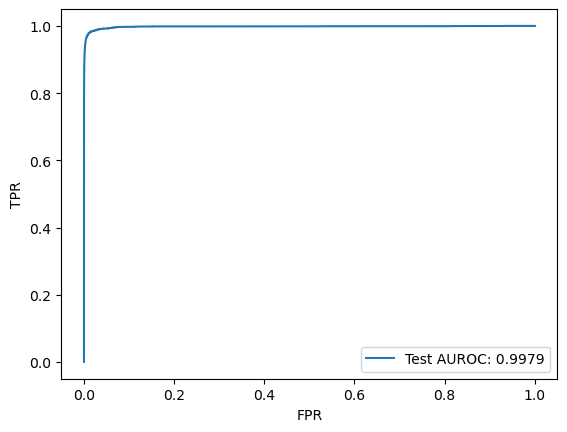

In [39]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.BDT, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

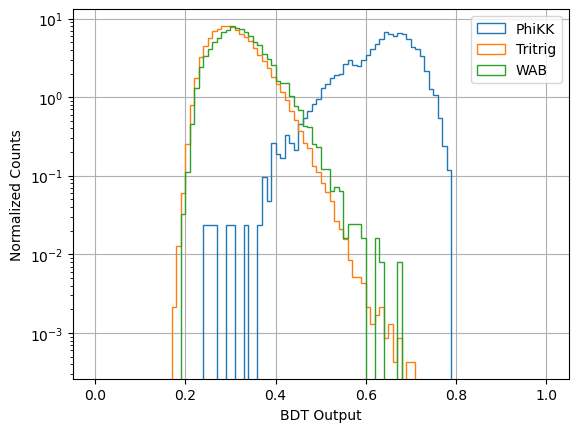

In [40]:
test_df_phiKK.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.BDT.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
#plt.axvline(x=0.4, color='k', linestyle='--', label ="selection line")
plt.xlabel('BDT Output')
plt.ylabel('Normalized Counts')
plt.yscale('log')
plt.legend()

Test AUROC: 0.9959


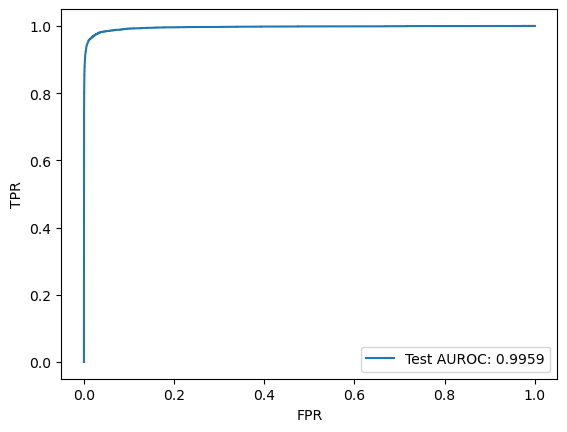

In [41]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_pre, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


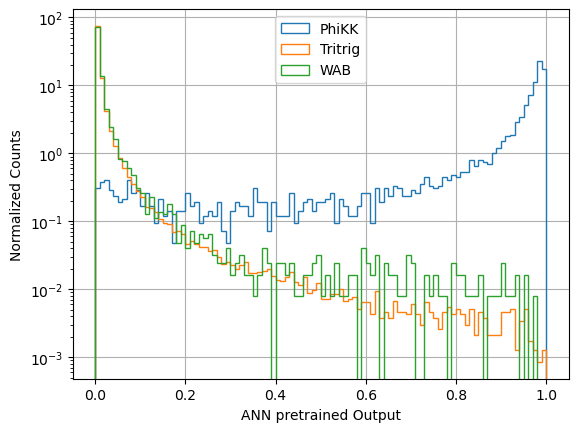

In [42]:
test_df_phiKK.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_pre.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN pretrained Output')
plt.ylabel('Normalized Counts')
plt.legend()

Test AUROC: 0.9902


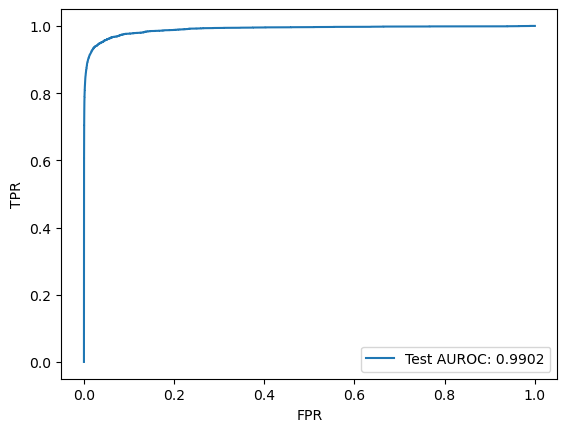

In [43]:

fpr, tpr, thresholds = sklearn.metrics.roc_curve(ANN_results.PhiKK, ANN_results.Class_adv, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


In [44]:
a =tpr/fpr

masked = np.ma.masked_invalid(a) # masks inf and nan
if masked.count() == 0: raise ValueError("No finite values")
idx = masked.argmax()

thresholds[idx]

/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_39921/3384453741.py:1: RuntimeWarning: divide by zero encountered in divide
  a =tpr/fpr
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_39921/3384453741.py:1: RuntimeWarning: invalid value encountered in divide
  a =tpr/fpr


np.float64(0.9879806964128031)

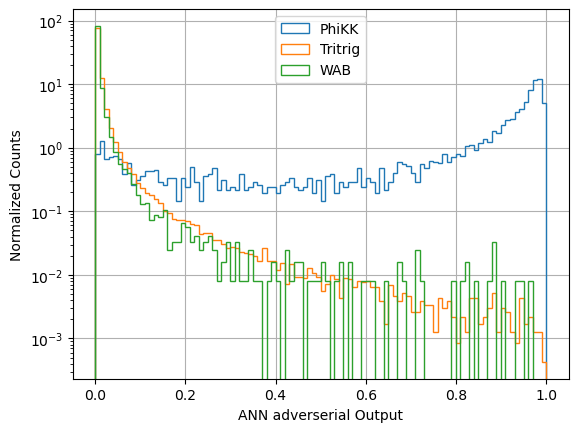

In [45]:
test_df_phiKK.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Class_adv.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
plt.yscale('log')
plt.xlabel('ANN adverserial Output')
plt.ylabel('Normalized Counts')
plt.legend()

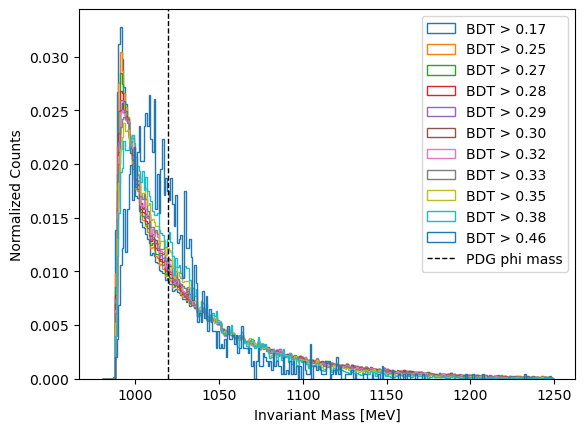

In [46]:
for sel in np.percentile(test_df_bkg['BDT'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['BDT']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'BDT > {sel:.2f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

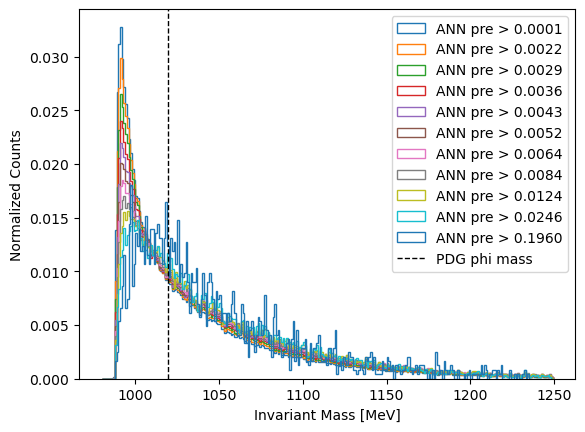

In [47]:
for sel in  np.percentile(test_df_bkg['Class_pre'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_pre']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN pre > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

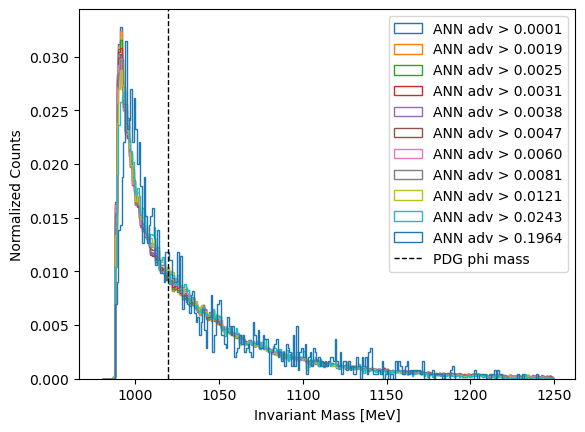

In [48]:
for sel in np.percentile(test_df_bkg['Class_adv'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['Class_adv']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN adv > {sel:.4f}', density=True)


plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

# Compare classifiers on weighted testing data

In [49]:
# Compine dfs according to expected proportions
df_test_combined = pd.concat([test_df_tritrig[0:136311], test_df_wab, test_df_phiKK[0:39]], ignore_index=True, sort=False)

print(len(df_test_combined))

148710


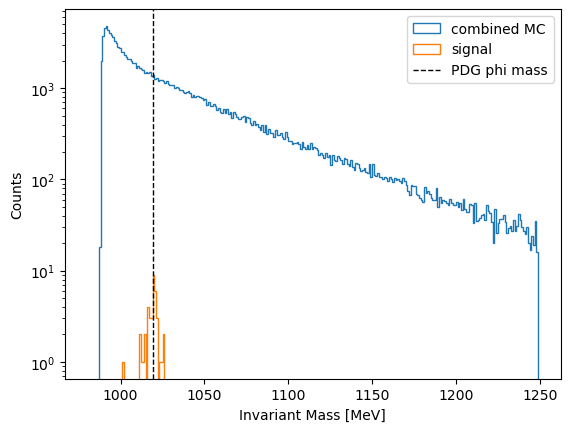

In [50]:
x_vals = 1000*df_test_combined.InvM
x_vals_sig = 1000*test_df_phiKK[0:39].InvM
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label="combined MC")
plt.hist(x_vals_sig, bins=np.arange(980,1250,1), histtype='step',label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

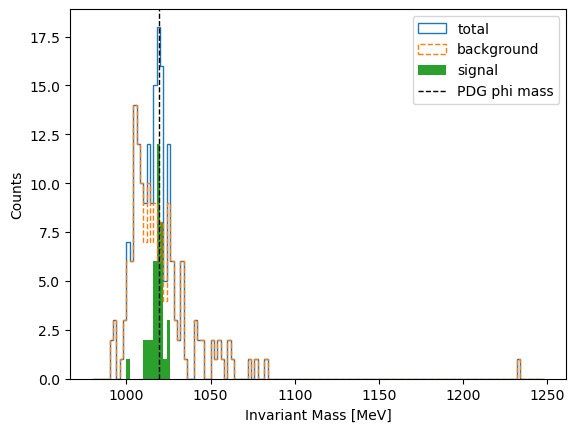

In [51]:
df_test_combined_cut = df_test_combined[df_test_combined['BDT']>np.percentile(test_df_bkg['BDT'],[99.9])[0]].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

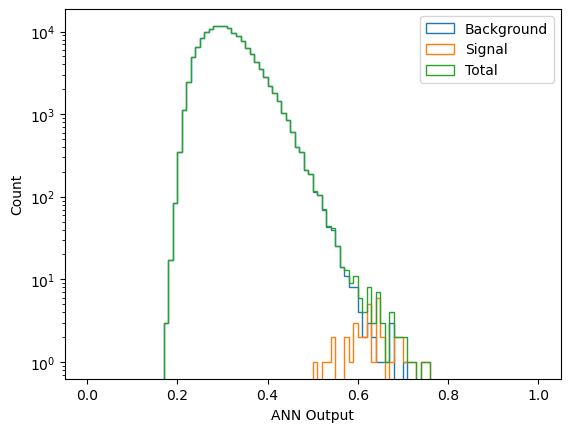

In [52]:
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['BDT'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.hist(df_test_combined['BDT'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

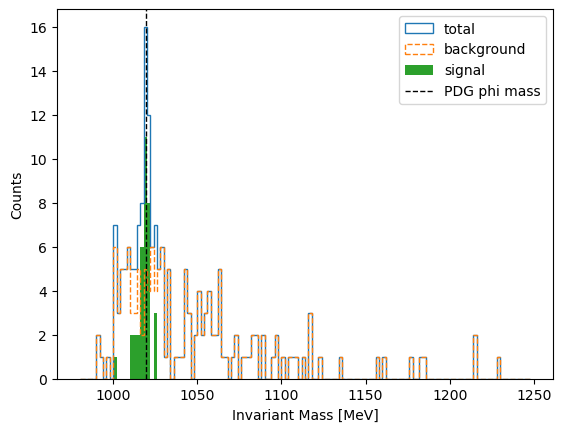

In [53]:
df_test_combined_cut = df_test_combined[df_test_combined['Class_pre']>np.percentile(test_df_bkg['Class_pre'],[99.9])[0]].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

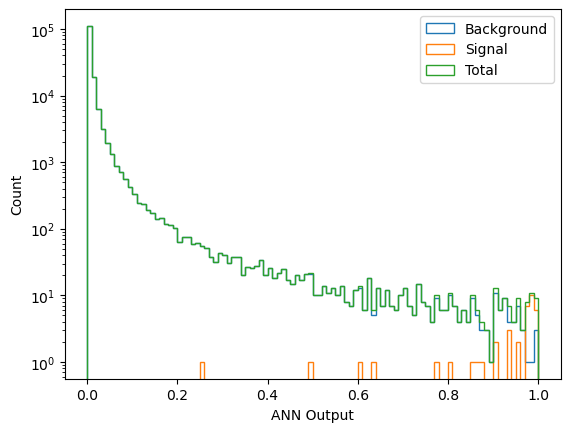

In [54]:
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_pre'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.hist(df_test_combined['Class_pre'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

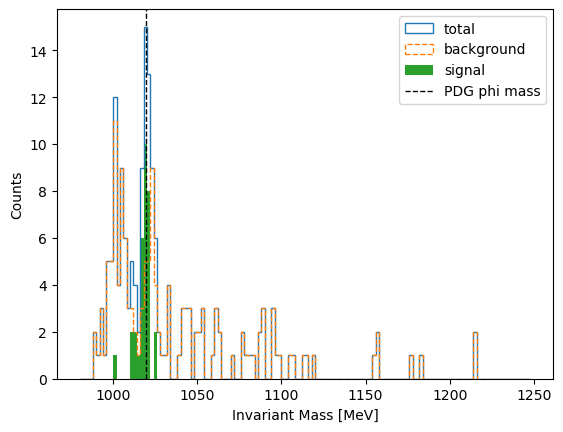

In [55]:
df_test_combined_cut = df_test_combined[df_test_combined['Class_adv']>np.percentile(test_df_bkg['Class_adv'],[99.9])[0]].reset_index(drop=True)
x_vals = 1000*df_test_combined_cut.InvM
x_vals_phiKK = 1000*df_test_combined_cut.loc[df_test_combined_cut.type=='phiKK'].InvM
x_bkg_vals_phiKK = 1000*df_test_combined_cut.loc[(df_test_combined_cut.type=='tritrig')|(df_test_combined_cut.type=='wab')].InvM



plt.hist(x_vals, bins=np.arange(980,1250,2), histtype='step',label="total")
plt.hist(x_bkg_vals_phiKK, bins=np.arange(980,1250,2), ls='--', histtype='step', label="background")
plt.hist(x_vals_phiKK, bins=np.arange(980,1250,2),label="signal")

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Text(0, 0.5, 'Count')

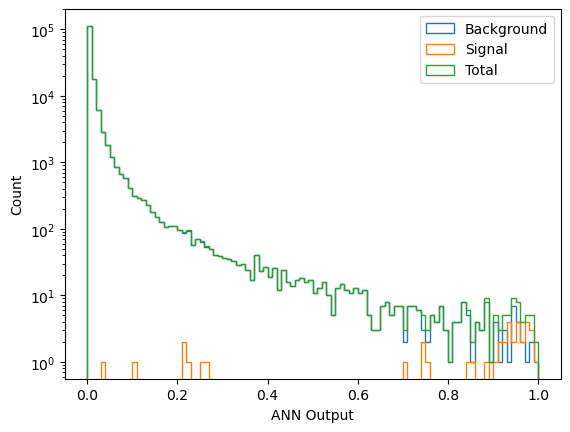

In [56]:
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 0],bins=np.arange(0,1.01,0.01), histtype='step',label='Background')
plt.hist(df_test_combined['Class_adv'].loc[df_test_combined.PhiKK == 1],bins=np.arange(0,1.01,0.01), histtype='step',label='Signal')
plt.hist(df_test_combined['Class_adv'],bins=np.arange(0,1.01,0.01), histtype='step',label='Total')

plt.legend()
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

# Apply ANN to data

In [57]:

X_final = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited_sideband_test_b.pk')

print(len(X_final))


60775


In [58]:
# simple MLP for binary classification (single logit output)
class Classifier(nn.Module):
    def __init__(self, in_features=X_final.shape[1], hidden1=264, hidden2=264, hidden3=128, hidden4=128, hidden5=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1,bias=False),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2,bias=False),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3,bias=False),
            nn.BatchNorm1d(hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, hidden4,bias=False),
            nn.BatchNorm1d(hidden4),
            nn.ReLU(),
            nn.Linear(hidden4, hidden5,bias=False),
            nn.BatchNorm1d(hidden5),
            nn.ReLU(),
            nn.Linear(hidden5, 1),
        )
    def forward(self, x):
        return self.net(x)
    
    

In [59]:
final_classifier = Classifier().to(device)
final_classifier.load_state_dict(torch.load("/Users/mghrear/data/ML_data/patch/classifier_adv_relu_run"+str(run)+"_limited_sideband_b.pt", map_location=device))
final_classifier.eval() 

Classifier(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=264, bias=False)
    (1): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=264, out_features=264, bias=False)
    (4): BatchNorm1d(264, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=264, out_features=128, bias=False)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=128, bias=False)
    (10): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=64, bias=False)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [60]:
final_dataset = TensorDataset(torch.from_numpy(X_final.to_numpy().astype(np.float32)) )
final_loader = DataLoader(final_dataset, batch_size=124, shuffle=False)

In [61]:
final_pred = mytools.test_final(final_loader, final_classifier, device)
final_pred=torch.sigmoid(torch.tensor(final_pred)).numpy()



Text(0, 0.5, 'Count')

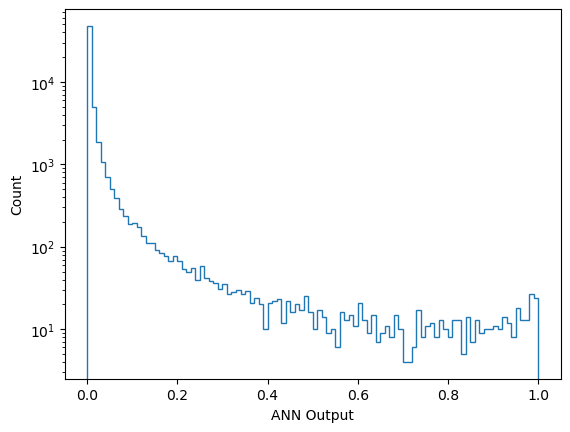

In [62]:
plt.hist(final_pred,bins=np.arange(0,1.01,0.01), histtype='step')
plt.yscale('log')
plt.xlabel('ANN Output')
plt.ylabel('Count')

In [63]:
X_final['pred'] = final_pred
X_final['InvM'] = mytools.get_InvM(X_final)

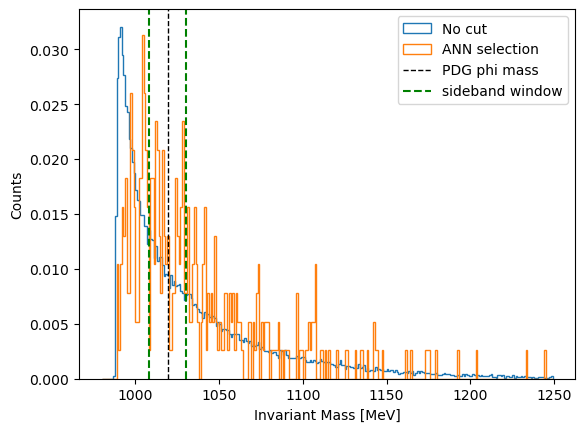

In [74]:
X_final_cut = X_final[X_final['pred']>np.percentile(test_df_bkg['Class_adv'],[99.9])[0]].reset_index(drop=True)
x_vals = 1000*X_final_cut.InvM

X_final_cut = X_final[X_final['pred']>0].reset_index(drop=True)
x_vals2 = 1000*X_final_cut.InvM

plt.hist(x_vals2, bins=np.arange(980,1250,1), label="No cut", histtype='step',density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), label="ANN selection", histtype='step',density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.axvline(1030.3173980209851, color='g', linestyle='--', label='sideband window')
plt.axvline(1008.4829302730138, color='g', linestyle='--')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

